## Project Overview
*The goal of this project is to show the intersection between Linear Algebra and Machine Learning, as well as a comparison between PCA and Logistic Regression. The dataset chosen for this is labeled faces of the wild.*

* To begin, the people who have at least 70 images in the dataset are extracted.
* The faces (matrices) are converted into vectors.
* With the collection of vectors, the average is computed, creating the average face.
* The average face is subtracted from all faces to leave unique features, creating the centered vectors.
* PCA makes use of the centered vectors to create a covariance matrix, from which eigenvectors are extracted. This leads to dimension reduction.
* PCA data is split in preparation for training the models.
* The SVM model uses the best parameters found before training and testing.
* After testing, the SVM model results are shown in a table and discussed.
* The Logistic Regression model is trained and tested with the same PCA data.
* A comparison between both models is shown in a bar chart, and the results are discussed.

In [2]:
from sklearn.datasets import fetch_lfw_people
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

[0.35369185 0.36522245 0.38784847 ... 0.45257366 0.426224   0.40011668]


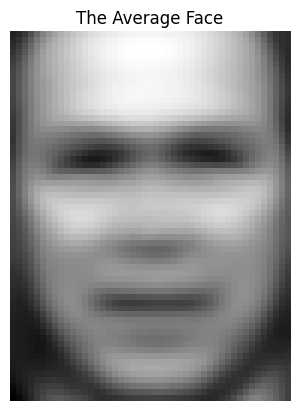

In [3]:
faces = fetch_lfw_people(min_faces_per_person=70)

faces_as_vectors = []
for face in faces.images:
    faces_as_vectors.append(np.ravel(face))
    
avg_face = np.mean(faces_as_vectors, axis=0)

print(avg_face)
plt.imshow(avg_face.reshape(62, 47), cmap = "gray")
plt.title("The Average Face")
plt.axis("off")
plt.show()

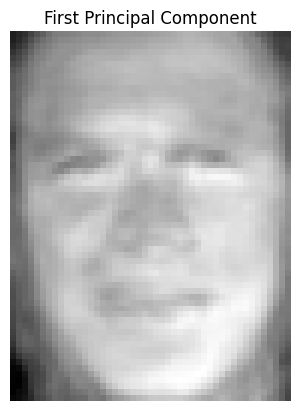

In [5]:
#Subtract the avg from faces to leave the unique differences only
faces_centered = faces_as_vectors - avg_face

#The number of eigenfaces
n_components = 150

pca = PCA(n_components=n_components, svd_solver="randomized", whiten=True).fit(faces_centered)

eigenfaces = pca.components_.reshape((n_components, 62, 47))

plt.imshow(eigenfaces[0], cmap='gray')
plt.title("First Principal Component")
plt.axis('off')
plt.show()

In [6]:
#Simplified dataset
X_pca = pca.transform(faces_centered)

print(f"Original shape: {faces_centered.shape}") 
print(f"Reduced shape: {X_pca.shape}")          

Original shape: (1288, 2914)
Reduced shape: (1288, 150)


In [7]:
from sklearn.model_selection import train_test_split

y = faces.target
target_names = faces.target_names

#Split data:
#75% training for the SVM
#25% testing to see if unseen data can be accurately identified
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.25, random_state=42
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"Number of unique people to recognize: {len(target_names)}")

Training set size: 966
Testing set size: 322
Number of unique people to recognize: 7


In [9]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [1e3, 5e3, 1e4, 5e4, 1e5],
    'gamma': [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.1]
}

# Set up the SVM to try every combination of the parameters above
# 'rbf' helps the computer handle non-linear face shapes by giving it the ability to draw curved lines
clf = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced'), param_grid
)

clf = clf.fit(X_train, y_train)

print(f"Best parameters found: {clf.best_params_}")

Best parameters found: {'C': 1000.0, 'gamma': 0.005}


In [26]:
from sklearn.metrics import classification_report


y_pred = clf.predict(X_test)

#Compares the computer's guesses (y_pred) to the actual names (y_test)
print(classification_report(y_test, y_pred, target_names=target_names))

                   precision    recall  f1-score   support

     Ariel Sharon       0.89      0.62      0.73        13
     Colin Powell       0.79      0.88      0.83        60
  Donald Rumsfeld       0.90      0.70      0.79        27
    George W Bush       0.83      0.97      0.90       146
Gerhard Schroeder       1.00      0.80      0.89        25
      Hugo Chavez       1.00      0.40      0.57        15
       Tony Blair       0.96      0.75      0.84        36

         accuracy                           0.85       322
        macro avg       0.91      0.73      0.79       322
     weighted avg       0.87      0.85      0.85       322



## Table Results
*A total of 322 images were tested across 7 different people. Overall, the model was able to correctly identify faces 84% of the time. The model was always correct when labeling photos for Gerhard Schroeder, Hugo Chavez, and Tony Blair. The model performed poorly when attempting to recognize Ariel Sharon and Hugo Chavez. It only recognized about 40-60% of the photos and missed the rest. This is due to the fact that Ariel Sharon and Hugo Chavez have the least amount of images, and because of this, the model had less practice with their faces. In contrast, images of George W Bush make up around 45% of the images, so the recognition accuracy for him was the highest. For this particular set of 322 images, it is clear that class imbalance negatively affects the machine's ability to accurately identify all of the 7 different faces.*

In [20]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(solver='lbfgs', max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

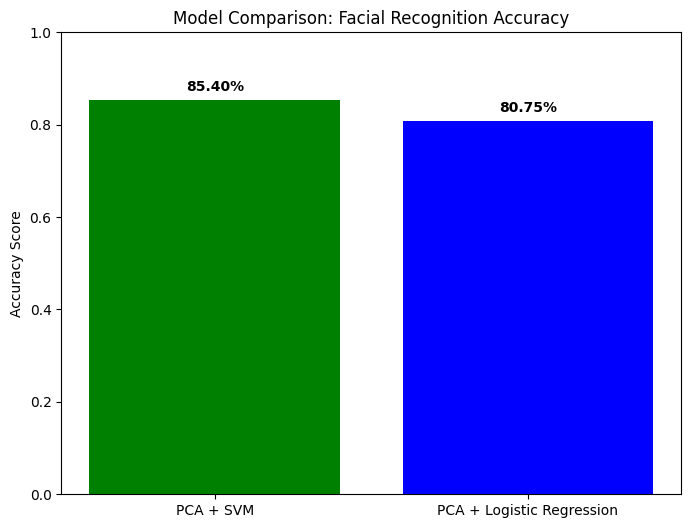

In [27]:
from sklearn.metrics import accuracy_score

svm_acc = accuracy_score(y_test, y_pred)
log_acc = accuracy_score(y_test, y_pred_log)

model_names = ['PCA + SVM', 'PCA + Logistic Regression']
scores = [svm_acc, log_acc]

plt.figure(figsize=(8, 6))
bars = plt.bar(model_names, scores, color=['g', 'b'])

plt.ylabel('Accuracy Score')
plt.title('Model Comparison: Facial Recognition Accuracy')
plt.ylim(0, 1.0) 

#The percentage labels for the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2%}', ha='center', fontweight='bold')

plt.show()

## Comparison Results
*The PCA + SVM model demonstrates a clear advantage over the PCA + Logistic Regression Model. Although both models utilized the same PCA-reduced dataset, the facial data is non-linear, so it is better suited for SVM, which has the ability to create non-linear boundaries, resulting in better performance over Logistic Regression, which is better suited for linearly separable data due to it being confined to using linear boundaries.*